isoNet Models Result Analysis
-------------------------------
This notebook is for analyzing the results of the isoNet models. It will load the combined results and break them down into sections based on the thesis outcomes.

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import numpy as np
import scipy.stats as stats
import sklearn.metrics as metrics
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
testResults = pd.read_csv(r"Combined_Test_Results.csv")
testResults['Date'] = pd.to_datetime(testResults['Date'], utc=True)
looResults = pd.read_csv(r"Combined_Leave_Out_Results.csv")
looResults['Date'] = pd.to_datetime(looResults['Date'], utc=True, format="mixed")

In [3]:
testResults['Scheme'].unique()

array(['Global', 'PreWinds'], dtype=object)

# Spatial Scheme Analysis

## Hypothesis Testsing
Is there a difference between the spatial schemes in terms of their performance on the test dataset? I will use a statistical test to determine if there is a significant difference between the two spatial schemes (Global, Prevailing Winds). I will use a paired t-test, since the same test dataset is being used for both spatial schemes. <br><br>
$H_0$: There is no difference between the spatial schemes in terms of their performance on the test dataset.<br>
$H_a$: There is a difference between the spatial schemes in terms of their performance on the test dataset.

In [4]:
ttest = stats.ttest_rel(testResults[testResults['Scheme'] == 'Global']['H2 P'], 
                        testResults[testResults['Scheme'] == 'PreWinds']['H2 P']) 

In [5]:
ttest

TtestResult(statistic=np.float64(1.528188272356638), pvalue=np.float64(0.12646590882325925), df=np.int64(2899199))

## Global Mapping
This section will map different metrics for the different spatial schemes for comparison

In [11]:
label_scheme_results = looResults.groupby(['Scheme', 'Label'])
label_scheme_results

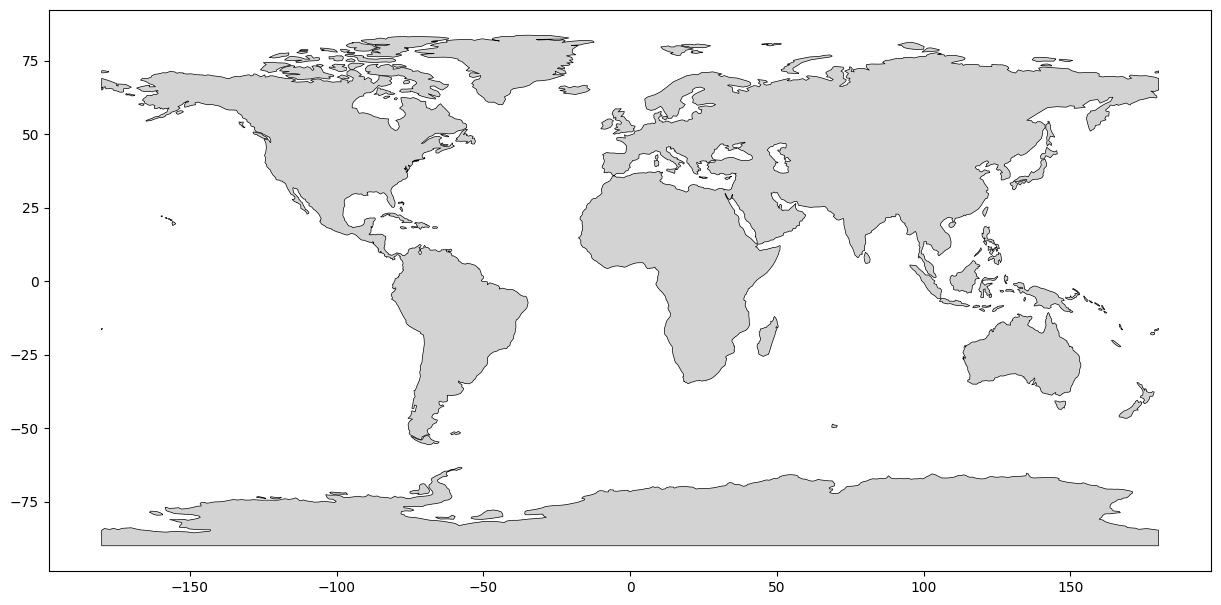

In [ ]:
# Develop a function that will take in a set of values, and produce a global map plotting the distribution of a metric
def plot_global_map(df, metric, title):
    # Setup world plot
    world = gpd.GeoDataFrame.from_file(geodatasets.get_path('naturalearth_land'))
    ax = world.plot(color='lightgray', edgecolor='black', linewidth=0.5, figsize=(15, 10))

    
    

plot_global_map(testResults, 'H2 P', 'Global Distribution of H2 P')